In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "data/processed/master_dataset_with_title_features.csv"
)

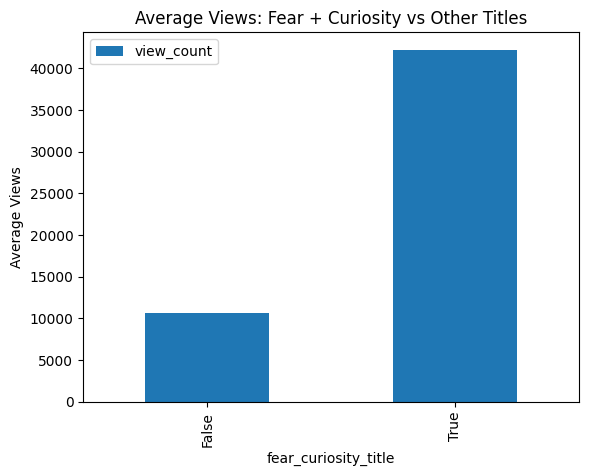

In [2]:
fear_curiosity_summary = (
    df.groupby("fear_curiosity_title")[
        ["view_count"]
    ]
    .mean()
)

fear_curiosity_summary.plot(
    kind="bar"
)

plt.title(
    "Average Views: Fear + Curiosity vs Other Titles"
)

plt.ylabel("Average Views")

plt.show()

In [3]:
top_videos = df[
    [
        "title",
        "view_count",
        "comment_count",
        "engagement_rate",
        "fear_title",
        "curiosity_title",
        "opportunity_title",
        "market_regime",
        "volatility_7d"
    ]
].sort_values(
    "view_count",
    ascending=False
)

top_videos.head(30)

,title,view_count,comment_count,engagement_rate,fear_title,curiosity_title,opportunity_title,market_regime,volatility_7d
52,UJAWNIAM PRAWDĘ O WOJNIE,375475,1154,0.030058,True,True,False,Bear,0.021660
675,Poradnik BINANCE FUTURES: Jak Grać Na Giełdzie...,158926,435,0.029108,False,False,False,Bear,0.044549
30,JAK ZONDA CRYPTO OKRADŁA 30 000 POLAKÓW?,100610,1141,0.040622,False,False,False,Bull,0.031401
49,UJAWNIAM ILE WOJNA Z IRANEM BĘDZIE WAS KOSZTOWAĆ,75306,431,0.044857,True,True,False,NaN,NaN
18,PREZYDENT USA CZY PRZESTĘPCA?,62971,518,0.057423,False,False,False,Bull,0.008492
513,10 ZASAD DZIĘKI KTÓRYM ZAROBIŁEM MILION NA KRY...,59796,383,0.060405,False,False,True,Bull,0.032312
663,Poradnik Jak Używać Poziomów Fibonacciego w An...,49960,100,0.032886,False,False,False,Bear,0.041686
498,TA STRATEGIA DAJE MI 90% WIN RATE NA KRYPTO (P...,48873,87,0.041925,False,False,True,Bear,0.029997
365,TO SIĘ KU*WA MUSI ŹLE SKOŃCZYĆ...,45043,215,0.045312,False,False,False,Bull,0.029955
229,SATOSHI NAKAMOTO ZNÓW ONLINE?!,43686,52,0.017717,False,False,False,Bull,0.014279


In [4]:
df["fear_curiosity_title"].value_counts()

fear_curiosity_title
False    681
True      15
Name: count, dtype: int64

In [5]:
top10 = df.sort_values(
    "view_count",
    ascending=False
).head(10)

top20 = df.sort_values(
    "view_count",
    ascending=False
).head(20)

top50 = df.sort_values(
    "view_count",
    ascending=False
).head(50)

print("Top 10:")
print(top10["fear_curiosity_title"].mean())

print("\nTop 20:")
print(top20["fear_curiosity_title"].mean())

print("\nTop 50:")
print(top50["fear_curiosity_title"].mean())

Top 10:
0.2

Top 20:
0.1

Top 50:
0.1


In [6]:
macro_words = [
    "WOJNA",
    "USA",
    "IRAN",
    "TRUMP",
    "PREZYDENT"
]

In [7]:
exchange_words = [
    "BINANCE",
    "BYBIT",
    "ZONDA"
]

In [8]:
trading_words = [
    "FUTURES",
    "STOP LOSS",
    "TRADING",
    "FIBONACCI"
]

In [9]:
investing_words = [
    "ZAROBIŁEM",
    "STRATEGIA",
    "WIN RATE",
    "INWESTOWAĆ"
]

In [10]:
df.groupby("macro_topic")[
    ["view_count", "comment_count"]
].mean()

KeyError: 'macro_topic'

In [11]:
def contains_any_word(title, word_list):
    title = str(title).upper()
    return any(word in title for word in word_list)

In [12]:
df["macro_topic"] = df["title"].apply(
    lambda x: contains_any_word(x, macro_words)
)

df["exchange_topic"] = df["title"].apply(
    lambda x: contains_any_word(x, exchange_words)
)

df["trading_topic"] = df["title"].apply(
    lambda x: contains_any_word(x, trading_words)
)

df["investing_topic"] = df["title"].apply(
    lambda x: contains_any_word(x, investing_words)
)

In [13]:
df[[
    "macro_topic",
    "exchange_topic",
    "trading_topic",
    "investing_topic"
]].sum()

macro_topic        37
exchange_topic     37
trading_topic      68
investing_topic    23
dtype: int64

In [15]:
df.groupby("macro_topic")[
    ["view_count", "comment_count", "engagement_rate"]
].mean()

,view_count,comment_count,engagement_rate
macro_topic,,,
False,11174.940819,51.006070,0.051947
True,13629.810811,52.837838,0.041314


In [16]:
df.groupby("exchange_topic")[
    ["view_count", "comment_count", "engagement_rate"]
].mean()

,view_count,comment_count,engagement_rate
exchange_topic,,,
False,10978.244310,48.379363,0.051915
True,17133.135135,99.621622,0.041888


In [17]:
df.groupby("trading_topic")[
    ["view_count", "comment_count", "engagement_rate"]
].mean()

,view_count,comment_count,engagement_rate
trading_topic,,,
False,11365.199045,52.694268,0.051761
True,10753.588235,36.411765,0.047882


In [18]:
df.groupby("investing_topic")[
    ["view_count", "comment_count", "engagement_rate"]
].mean()

,view_count,comment_count,engagement_rate
investing_topic,,,
False,10974.325409,49.780089,0.051421
True,20994.260870,89.826087,0.050225


In [19]:
df["fear_curiosity_investing"] = (
    (df["fear_curiosity_title"] == True)
    &
    (df["investing_topic"] == True)
)

In [20]:
df.groupby(
    "fear_curiosity_investing"
)[
    [
        "view_count",
        "comment_count",
        "engagement_rate"
    ]
].mean()

,view_count,comment_count,engagement_rate
fear_curiosity_investing,,,
False,11305.443966,51.103448,0.051382


In [21]:
df["fear_curiosity_investing"].value_counts()

fear_curiosity_investing
False    696
Name: count, dtype: int64

In [22]:
df["fear_curiosity_macro"] = (
    (df["fear_curiosity_title"] == True)
    &
    (df["macro_topic"] == True)
)

In [23]:
df["fear_curiosity_macro"].value_counts()

fear_curiosity_macro
False    694
True       2
Name: count, dtype: int64

In [24]:
df.groupby(
    "fear_curiosity_macro"
)[
    [
        "view_count",
        "comment_count",
        "engagement_rate"
    ]
].mean()

,view_count,comment_count,engagement_rate
fear_curiosity_macro,,,
False,11222.739193,50.62536,0.051428
True,40004.000000,217.00000,0.035189


In [25]:
top10 = df.sort_values(
    "view_count",
    ascending=False
).head(10)

top20 = df.sort_values(
    "view_count",
    ascending=False
).head(20)

top50 = df.sort_values(
    "view_count",
    ascending=False
).head(50)

print("Top 10:", top10["fear_curiosity_title"].sum())
print("Top 20:", top20["fear_curiosity_title"].sum())
print("Top 50:", top50["fear_curiosity_title"].sum())

Top 10: 2
Top 20: 2
Top 50: 5


In [26]:
df["top_10_percent"] = (
    df["view_count"]
    >= df["view_count"].quantile(0.90)
)

In [27]:
df["top_10_percent"].value_counts()

top_10_percent
False    626
True      70
Name: count, dtype: int64

In [28]:
df[
    df["top_10_percent"] == True
][
    [
        "title",
        "view_count"
    ]
].sort_values(
    "view_count",
    ascending=False
)

,title,view_count
52,UJAWNIAM PRAWDĘ O WOJNIE,375475
675,Poradnik BINANCE FUTURES: Jak Grać Na Giełdzie...,158926
30,JAK ZONDA CRYPTO OKRADŁA 30 000 POLAKÓW?,100610
49,UJAWNIAM ILE WOJNA Z IRANEM BĘDZIE WAS KOSZTOWAĆ,75306
18,PREZYDENT USA CZY PRZESTĘPCA?,62971
...,...,...
403,UWAGA: ZACZĄŁEM SPRZEDAWAĆ WSZYSTKIE SWOJE BIT...,19900
326,PILNE: RYNEK KRWAWI. CZY WCHODZIMY W BESSĘ ?,19885
448,KU*WA OBUDŹ SIĘ CHŁOPIE,19827
380,MÓJ PLAN NA ZAROBIENIE MILIONÓW W HOSSIE 2025 ...,19355


In [29]:
pd.set_option("display.max_colwidth", None)

In [30]:
df[
    df["top_10_percent"] == True
][
    [
        "title",
        "view_count"
    ]
].sort_values(
    "view_count",
    ascending=False
)

,title,view_count
52,UJAWNIAM PRAWDĘ O WOJNIE,375475
675,Poradnik BINANCE FUTURES: Jak Grać Na Giełdzie Kryptowalut Z Dźwignią (2022),158926
30,JAK ZONDA CRYPTO OKRADŁA 30 000 POLAKÓW?,100610
49,UJAWNIAM ILE WOJNA Z IRANEM BĘDZIE WAS KOSZTOWAĆ,75306
18,PREZYDENT USA CZY PRZESTĘPCA?,62971
...,...,...
403,UWAGA: ZACZĄŁEM SPRZEDAWAĆ WSZYSTKIE SWOJE BITCOINY (CO DALEJ?),19900
326,PILNE: RYNEK KRWAWI. CZY WCHODZIMY W BESSĘ ?,19885
448,KU*WA OBUDŹ SIĘ CHŁOPIE,19827
380,MÓJ PLAN NA ZAROBIENIE MILIONÓW W HOSSIE 2025 (STRATEGIA WYJŚCIA),19355


In [31]:
top_10_df = df[
    df["top_10_percent"] == True
]

top_10_df.to_csv(
    "reports/top_10_percent_videos.csv",
    index=False,
    encoding="utf-8-sig"
)

In [32]:
from collections import Counter
import re

In [33]:
titles = df[
    df["top_10_percent"] == True
]["title"]

all_words = []

for title in titles:
    words = re.findall(
        r"\b\w+\b",
        str(title).upper()
    )

    all_words.extend(words)

word_counts = Counter(all_words)

word_counts.most_common(50)

[('NA', 25),
 ('JAK', 21),
 ('PORADNIK', 15),
 ('W', 12),
 ('Z', 11),
 ('TO', 8),
 ('SIĘ', 8),
 ('CO', 7),
 ('STRATEGIA', 7),
 ('KRYPTO', 7),
 ('000', 6),
 ('KRYPTOWALUT', 6),
 ('I', 6),
 ('2022', 6),
 ('PILNE', 5),
 ('KTÓRE', 5),
 ('2025', 5),
 ('BINANCE', 5),
 ('UJAWNIAM', 4),
 ('BITCOINA', 4),
 ('NIE', 4),
 ('ALTCOINÓW', 4),
 ('KRYPTOWALUTACH', 4),
 ('BYBIT', 4),
 ('FUTURES', 4),
 ('USA', 3),
 ('CZY', 3),
 ('PO', 3),
 ('ALTSEASON', 3),
 ('DALEJ', 3),
 ('10X', 3),
 ('BTC', 3),
 ('1', 3),
 ('PRZED', 3),
 ('TRUMPA', 3),
 ('UWAGA', 3),
 ('NADCHODZI', 3),
 ('TOP', 3),
 ('DZIĘKI', 3),
 ('GRAĆ', 3),
 ('GIEŁDZIE', 3),
 ('DŹWIGNIĄ', 3),
 ('10', 3),
 ('2024', 3),
 ('PIENIĄDZE', 3),
 ('ZONDA', 2),
 ('CRYPTO', 2),
 ('30', 2),
 ('BĘDZIE', 2),
 ('WSZYSTKIE', 2)]

In [34]:
pd.set_option("display.max_colwidth", None)

In [35]:
word_counts.most_common(50)

[('NA', 25),
 ('JAK', 21),
 ('PORADNIK', 15),
 ('W', 12),
 ('Z', 11),
 ('TO', 8),
 ('SIĘ', 8),
 ('CO', 7),
 ('STRATEGIA', 7),
 ('KRYPTO', 7),
 ('000', 6),
 ('KRYPTOWALUT', 6),
 ('I', 6),
 ('2022', 6),
 ('PILNE', 5),
 ('KTÓRE', 5),
 ('2025', 5),
 ('BINANCE', 5),
 ('UJAWNIAM', 4),
 ('BITCOINA', 4),
 ('NIE', 4),
 ('ALTCOINÓW', 4),
 ('KRYPTOWALUTACH', 4),
 ('BYBIT', 4),
 ('FUTURES', 4),
 ('USA', 3),
 ('CZY', 3),
 ('PO', 3),
 ('ALTSEASON', 3),
 ('DALEJ', 3),
 ('10X', 3),
 ('BTC', 3),
 ('1', 3),
 ('PRZED', 3),
 ('TRUMPA', 3),
 ('UWAGA', 3),
 ('NADCHODZI', 3),
 ('TOP', 3),
 ('DZIĘKI', 3),
 ('GRAĆ', 3),
 ('GIEŁDZIE', 3),
 ('DŹWIGNIĄ', 3),
 ('10', 3),
 ('2024', 3),
 ('PIENIĄDZE', 3),
 ('ZONDA', 2),
 ('CRYPTO', 2),
 ('30', 2),
 ('BĘDZIE', 2),
 ('WSZYSTKIE', 2)]

In [36]:
stop_words = [
    "NA",
    "JAK",
    "W",
    "Z",
    "TO",
    "SIĘ",
    "CO",
    "PO",
    "I",
    "NIE",
    "KTÓRE",
    "CZY",
    "000",
    "2022",
    "2024",
    "2025",
    "1",
    "10",
    "30"
]

In [37]:
filtered_counts = {
    word: count
    for word, count in word_counts.items()
    if word not in stop_words
}

In [38]:
from collections import Counter

filtered_counts = Counter(filtered_counts)

filtered_counts.most_common(30)

[('PORADNIK', 15),
 ('STRATEGIA', 7),
 ('KRYPTO', 7),
 ('KRYPTOWALUT', 6),
 ('PILNE', 5),
 ('BINANCE', 5),
 ('UJAWNIAM', 4),
 ('BITCOINA', 4),
 ('ALTCOINÓW', 4),
 ('KRYPTOWALUTACH', 4),
 ('BYBIT', 4),
 ('FUTURES', 4),
 ('USA', 3),
 ('ALTSEASON', 3),
 ('DALEJ', 3),
 ('10X', 3),
 ('BTC', 3),
 ('PRZED', 3),
 ('TRUMPA', 3),
 ('UWAGA', 3),
 ('NADCHODZI', 3),
 ('TOP', 3),
 ('DZIĘKI', 3),
 ('GRAĆ', 3),
 ('GIEŁDZIE', 3),
 ('DŹWIGNIĄ', 3),
 ('PIENIĄDZE', 3),
 ('ZONDA', 2),
 ('CRYPTO', 2),
 ('BĘDZIE', 2)]

In [39]:
top_words_df = pd.DataFrame(
    filtered_counts.most_common(20),
    columns=["word", "count"]
)

top_words_df

,word,count
0,PORADNIK,15
1,STRATEGIA,7
2,KRYPTO,7
3,KRYPTOWALUT,6
4,PILNE,5
5,BINANCE,5
6,UJAWNIAM,4
7,BITCOINA,4
8,ALTCOINÓW,4
9,KRYPTOWALUTACH,4


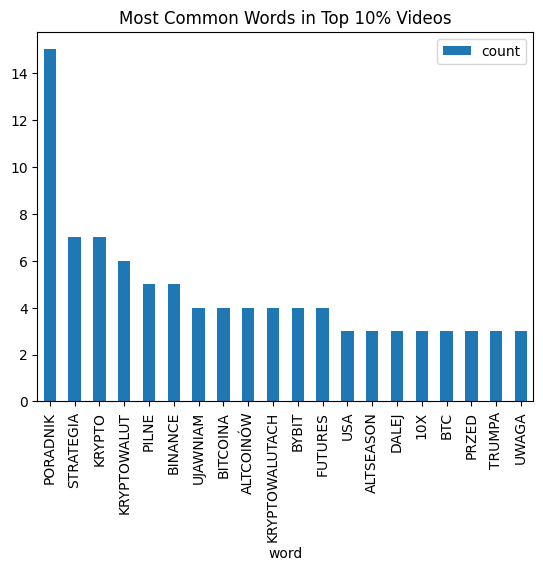

In [40]:
top_words_df.plot(
    x="word",
    y="count",
    kind="bar"
)

plt.title(
    "Most Common Words in Top 10% Videos"
)

plt.show()

In [41]:
fear_words = [
    "WOJNA",
    "KONIEC",
    "KRYZYS",
    "PRZESTĘPCA",
    "OKRADŁA",
    "PILNE",
    "UWAGA"
]

In [42]:
curiosity_words = [
    "UJAWNIAM",
    "PRAWDA",
    "NIKT",
    "SEKRET"
]

In [43]:
opportunity_words = [
    "10X",
    "STRATEGIA",
    "ZAROBIŁEM",
    "ALTSEASON"
]

In [44]:
def score_title(title, words):
    title = str(title).upper()
    return sum(
        word in title
        for word in words
    )

In [45]:
df["fear_score"] = df["title"].apply(
    lambda x: score_title(x, fear_words)
)

df["curiosity_score"] = df["title"].apply(
    lambda x: score_title(x, curiosity_words)
)

df["opportunity_score"] = df["title"].apply(
    lambda x: score_title(x, opportunity_words)
)

In [46]:
df.groupby("fear_score")[
    ["view_count"]
].mean()

,view_count
fear_score,
0,10761.425361
1,15998.816901
2,14152.500000


In [47]:
df.groupby("curiosity_score")[
    ["view_count"]
].mean()

,view_count
curiosity_score,
0,10624.511013
1,44103.285714
2,15851.000000


In [48]:
df.groupby("opportunity_score")[
    ["view_count"]
].mean()

,view_count
opportunity_score,
0,10874.223926
1,17616.465116
2,21087.000000


In [49]:
df["video_age_days"] = (
    pd.Timestamp.now()
    - pd.to_datetime(df["published_at"])
).dt.days

TypeError: Cannot subtract tz-naive and tz-aware datetime-like objects

In [50]:
df[[
    "video_age_days",
    "view_count"
]].corr()

KeyError: "['video_age_days'] not in index"

In [51]:
df["video_age_days"] = (
    pd.Timestamp.now(tz="UTC")
    - pd.to_datetime(df["published_at"])
).dt.days

In [52]:
df[[
    "video_age_days",
    "view_count"
]].corr()

,video_age_days,view_count
video_age_days,1.000000,-0.026728
view_count,-0.026728,1.000000


In [53]:
df.sort_values(
    "engagement_rate",
    ascending=False
)[
    [
        "title",
        "view_count",
        "engagement_rate"
    ]
].head(20)

,title,view_count,engagement_rate
545,CO TU SIĘ WYDARZYŁO❓ BITCOIN | ALTCOINY PODSUMOWANIE 2023,1165,0.300429
666,Poleciałem Do Luksemburga Żeby Zainwestować w MEGA Projekt!,1428,0.127451
571,ZAROBILI 2.500.000$ na MANIPULACJI ! | MARKET UPDATE #17,1734,0.127451
200,2 MIN KTÓRE ZROBIĄ Z CIEBIE KRYPTO TRYLIARDERA,8042,0.109177
659,Jak Uchronić Się Przed KOLOSALNYMI STRATAMI w Na Rynku Kryptowalut,1422,0.109001
596,Czy Coinbase Upadnie? Zagrania Na SOL oraz BTC | Market Update #8,1221,0.107289
598,BTC Zostanie Wkońcu Uregulowany?? | MARKET UPDATE #7,1361,0.105805
568,"BTC,ADA,XRP - CZY ZACZYNAMY HOSSE NA ALTACH ? | MARKET UPDATE #18",3986,0.104867
540,CO ROBIĆ ABY NIE TRACIĆ PIENIĘDZY NA KRYPTO❓ TRADING PODCAST - PSYCHOLOGIA 🧠,3325,0.103459
573,ETF ZAGROŻENIEM DLA BITCOIN | SPEKULACJA KRYPTOWALUTY 2024,4053,0.102640


In [54]:
df[[
    "view_count",
    "like_count",
    "comment_count",
    "engagement_rate",
    "video_age_days",
    "fear_score",
    "curiosity_score",
    "opportunity_score"
]].corr()

,view_count,like_count,comment_count,engagement_rate,video_age_days,fear_score,curiosity_score,opportunity_score
view_count,1.000000,0.935262,0.794804,-0.087628,-0.026728,0.088655,0.241589,0.094922
like_count,0.935262,1.000000,0.830229,0.087877,-0.060664,0.157670,0.266055,0.149015
comment_count,0.794804,0.830229,1.000000,0.150134,0.043407,0.154533,0.213040,0.099520
engagement_rate,-0.087628,0.087877,0.150134,1.000000,0.272612,0.046040,0.053936,-0.003516
video_age_days,-0.026728,-0.060664,0.043407,0.272612,1.000000,-0.139338,-0.022468,0.071544
fear_score,0.088655,0.157670,0.154533,0.046040,-0.139338,1.000000,0.092639,0.002698
curiosity_score,0.241589,0.266055,0.213040,0.053936,-0.022468,0.092639,1.000000,0.034629
opportunity_score,0.094922,0.149015,0.099520,-0.003516,0.071544,0.002698,0.034629,1.000000


In [55]:
df["viral_score"] = (
    df["fear_score"] * 1
    + df["curiosity_score"] * 2
    + df["opportunity_score"] * 1
)

In [56]:
df.groupby("viral_score")[
    "view_count"
].mean()

viral_score
0     9614.786087
1    15995.929293
2    40002.733333
3    23794.200000
4    18739.000000
Name: view_count, dtype: float64

In [57]:
df["viral_score"].value_counts()

viral_score
0    575
1     99
2     15
3      5
4      2
Name: count, dtype: int64

In [58]:
df["fear_curiosity"] = (
    (df["fear_score"] > 0)
    &
    (df["curiosity_score"] > 0)
)

df.groupby(
    "fear_curiosity"
)[
    [
        "view_count",
        "comment_count",
        "engagement_rate"
    ]
].mean()

,view_count,comment_count,engagement_rate
fear_curiosity,,,
False,11202.043415,50.493488,0.051390
True,25595.400000,135.400000,0.050162


In [59]:
top20 = df.sort_values(
    "view_count",
    ascending=False
).head(20)

top20[[
    "title",
    "fear_score",
    "curiosity_score",
    "opportunity_score",
    "view_count"
]]

,title,fear_score,curiosity_score,opportunity_score,view_count
52,UJAWNIAM PRAWDĘ O WOJNIE,0,1,0,375475
675,Poradnik BINANCE FUTURES: Jak Grać Na Giełdzie Kryptowalut Z Dźwignią (2022),0,0,0,158926
30,JAK ZONDA CRYPTO OKRADŁA 30 000 POLAKÓW?,1,0,0,100610
49,UJAWNIAM ILE WOJNA Z IRANEM BĘDZIE WAS KOSZTOWAĆ,1,1,0,75306
18,PREZYDENT USA CZY PRZESTĘPCA?,1,0,0,62971
513,10 ZASAD DZIĘKI KTÓRYM ZAROBIŁEM MILION NA KRYPTOWALUTACH !,0,0,1,59796
663,Poradnik Jak Używać Poziomów Fibonacciego w Analizie Technicznej 2025,0,0,0,49960
498,TA STRATEGIA DAJE MI 90% WIN RATE NA KRYPTO (PORADNIK),0,0,1,48873
365,TO SIĘ KU*WA MUSI ŹLE SKOŃCZYĆ...,0,0,0,45043
229,SATOSHI NAKAMOTO ZNÓW ONLINE?!,0,0,0,43686


In [60]:
tutorial_words = [
    "JAK",
    "PORADNIK",
    "KURS",
    "USTAWIC",
    "UZYWAC"
]

df["tutorial title"] = (
    df["title"]
    .str.upper()
    .apply(
        lambda x: any(
            word in x
            for word in tutorial_words
        )
    )
)

In [61]:
df.groupby("tutorial_title")[
    [
        "view_count",
        "comment_count",
        "engagement_rate"
    ]
    ].mean()

KeyError: 'tutorial_title'

In [62]:
tutorial_words = [
    "JAK",
    "PORADNIK",
    "KURS",
    "USTAWIĆ",
    "UZYWAĆ"
]

In [63]:
df["tutorial_title"].value_counts()

KeyError: 'tutorial_title'

In [64]:
df.columns.tolist()

['video_id',
 'title',
 'published_at',
 'description',
 'channel_title',
 'category_id',
 'duration',
 'view_count',
 'like_count',
 'comment_count',
 'year_x',
 'month_x',
 'month_name_x',
 'duration_minutes',
 'engagement_rate',
 'weekday_x',
 'weekday_num',
 'publish_hour',
 'publish_year_month',
 'like_rate',
 'comment_rate',
 'upload_date',
 'Unix',
 'Date',
 'Symbol',
 'Open',
 'High',
 'Low',
 'Close',
 'Volume BTC',
 'Volume USDT',
 'tradecount',
 'daily_return',
 'volatility_7d',
 'ma_7',
 'ma_30',
 'ma_90',
 'bull_market',
 'year_y',
 'month_y',
 'month_name_y',
 'weekday_y',
 'market_regime',
 'btc_date',
 'volatility_bucket',
 'title_length',
 'title_word_count',
 'fear_title',
 'curiosity_title',
 'opportunity_title',
 'conflict_title',
 'fear_curiosity_title',
 'macro_topic',
 'exchange_topic',
 'trading_topic',
 'investing_topic',
 'fear_curiosity_investing',
 'fear_curiosity_macro',
 'top_10_percent',
 'fear_score',
 'curiosity_score',
 'opportunity_score',
 'video_age

In [65]:
df.["tutorial title"].value_counts()

SyntaxError: invalid syntax (941262349.py, line 1)

In [66]:
df[

SyntaxError: incomplete input (3910388838.py, line 1)

In [67]:
df["tutorial title"].value_counts()

tutorial title
False    566
True     130
Name: count, dtype: int64

In [68]:
df = df.rename(columns={"tutorial title": "tutorial_title"})

In [70]:
df["tutorial_title"].value_counts()

tutorial_title
False    566
True     130
Name: count, dtype: int64

In [71]:
df.groupby("tutorial_title")[
    [
        "view_count",
        "comment_count",
        "engagement_rate"
    ]
    ].mean()

,view_count,comment_count,engagement_rate
tutorial_title,,,
False,10535.869258,47.439929,0.051409
True,14656.053846,67.053846,0.051263


In [72]:
df[
    df[

SyntaxError: incomplete input (1916250715.py, line 2)

In [73]:
df[
    df["tutorial_title"] == True
    ][
        [
            "title",
            "view_count",
            "comment_count",
            "engagement_rate"
        ]
    ].sort_values(
        "view_count",
        ascending=False
    ).head(20)

,title,view_count,comment_count,engagement_rate
675,Poradnik BINANCE FUTURES: Jak Grać Na Giełdzie Kryptowalut Z Dźwignią (2022),158926,435,0.029108
30,JAK ZONDA CRYPTO OKRADŁA 30 000 POLAKÓW?,100610,1141,0.040622
663,Poradnik Jak Używać Poziomów Fibonacciego w Analizie Technicznej 2025,49960,100,0.032886
498,TA STRATEGIA DAJE MI 90% WIN RATE NA KRYPTO (PORADNIK),48873,87,0.041925
687,Jak Wpłacić / Wypłacić Pieniądze z Binance (OMIJAJĄC KOSZTA) | Binance Poradnik 2022,43641,240,0.026237
503,PORADNIK Jak Grać Na Giełdzie Kryptowalut Z Dźwignią (BEZPIECZNY SPOSÓB NA 100X),43370,124,0.037722
660,Najłatwiejsza Metoda Znajdowania Okazji Tradingowych | Poradnik Day Tradingu,40225,48,0.035053
617,Jak Przewidywać Ruchy na Wykresie Kryptowalut (MINI KURS),40108,63,0.039194
684,Jak Ustawić i Używać STOP LOSS / STOP LIMIT Na Binance | Poradnik Binance 2022,40067,73,0.021289
643,PORADNIK Jak Wpłacić Pieniądze Na ByBit (BEZ KOSZTÓW),38730,177,0.022360


In [74]:
top10 = df[
    df["view_count"]
    >= df["view_count"].quantile(0.90)
    ]

print(top10.shape)

(70, 66)


In [ ]:
top10[
    [
        "title",
        "view_count",
        "comment_count",
        "engagement_rate"
    ]
    ].sort_values(
        "view_count",
        ascending=False
    ).head(30)